In [1]:
#@title **MONTAR EL DRIVE** { display-mode: "form" }
import os
from google.colab import drive

path_ai = "ProyectoAI1" #@param {type:"string"}
path = "/content/drive/My Drive/" + path_ai
drive.mount('/content/drive')
os.chdir(path)
print(os.getcwd())

Mounted at /content/drive
/content/drive/My Drive/ProyectoAI1


In [2]:
import os
import numpy as np
import torch
import cv2
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.feature import hog, local_binary_pattern
from sklearn.preprocessing import LabelEncoder
from pathlib import Path
from tqdm import tqdm
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando: {device}")

Usando: cuda


# RESNET

In [ ]:
resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
resnet = torch.nn.Sequential(*list(resnet.children())[:-1])
resnet = resnet.to(device)
resnet.eval()

print("   ResNet50 cargada")
print("   Output por imagen: 2048 features")

   ResNet50 cargada
   Output por imagen: 2048 features


# Cargar imagenes

In [ ]:
BASE_PATH ="Dataset_Ext"


transform = transforms.Compose([
    transforms.Resize((128, 128)), #CAMBIAR EL TAMAÑO DE LA IMAGEN
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])

class GarbageDataset(Dataset):
    def __init__(self, base_path, transform=None):
        self.samples = []   # (ruta, label_str)
        self.transform = transform

        clases = sorted([f for f in os.listdir(base_path)
                         if os.path.isdir(os.path.join(base_path, f))])

        for label in clases:
            class_path = os.path.join(base_path, label)
            for fname in os.listdir(class_path):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                    self.samples.append((os.path.join(class_path, fname), label))

        print(f" {len(self.samples)} imágenes encontradas")
        print(f"   Clases: {clases}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

dataset = GarbageDataset(BASE_PATH, transform=transform)
loader  = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=2)

 7010 imágenes encontradas
   Clases: ['cardboard', 'glass', 'metal', 'paper', 'plastic']


# Caracteristicas manuales

In [ ]:
import cv2
import numpy as np
from pathlib import Path
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from skimage.feature import hog, local_binary_pattern

# ── Configuración ─────────────────────────────────────────────────
IMG_SIZE       = (128, 128)
DATA_DIR       = "Dataset_Ext"
EXTENSIONES    = ("*.jpg", "*.jpeg", "*.png")

HOG_ORIENTATIONS = 9
HOG_PIXELS_CELL  = (8, 8)
HOG_CELLS_BLOCK  = (2, 2)
LBP_RADIUS       = 3
LBP_POINTS       = 8 * LBP_RADIUS
LBP_BINS         = 64
COLOR_BINS       = 32

# ── Funciones ─────────────────────────────────────────────────────
def extract_hog(gray):
    return hog(
        gray,
        orientations    = HOG_ORIENTATIONS,
        pixels_per_cell = HOG_PIXELS_CELL,
        cells_per_block = HOG_CELLS_BLOCK,
        block_norm      = "L2-Hys",
        transform_sqrt  = True
    )

def extract_lbp(gray):
    lbp       = local_binary_pattern(gray, LBP_POINTS, LBP_RADIUS, method="uniform")
    hist, _   = np.histogram(lbp.ravel(), bins=LBP_BINS, range=(0, LBP_BINS))
    return hist.astype(np.float32) / (hist.sum() + 1e-6)

def extract_color_histogram(img_bgr):
    hsv  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    hist = []
    for ch in range(3):
        h, _ = np.histogram(hsv[:, :, ch], bins=COLOR_BINS, range=(0, 256))
        hist.append(h.astype(np.float32) / (h.sum() + 1e-6))
    return np.concatenate(hist)

def extract_features(img_path):
    img = cv2.imread(str(img_path))
    if img is None:
        return None
    img  = cv2.resize(img, IMG_SIZE)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return np.concatenate([
        extract_hog(gray),
        extract_lbp(gray),
        extract_color_histogram(img)
    ])

# ── Recolectar rutas de todas las extensiones ─────────────────────
image_paths = []
for ext in EXTENSIONES:
    image_paths += sorted(Path(DATA_DIR).rglob(ext))

print(f"Total imágenes encontradas: {len(image_paths)}")

# ── Loop principal ────────────────────────────────────────────────
all_features, all_labels = [], []

for img_path in tqdm(image_paths, desc="Extrayendo features"):
    feat = extract_features(img_path)
    if feat is None:
        print(f"  ⚠ No se pudo leer: {img_path}")
        continue
    all_features.append(feat)
    all_labels.append(img_path.parent.name)

X      = np.vstack(all_features)
labels = np.array(all_labels)
le     = LabelEncoder()
y      = le.fit_transform(labels)

# ── Resumen ───────────────────────────────────────────────────────
hog_size   = len(extract_hog(np.zeros(IMG_SIZE, dtype=np.uint8)))
color_size = COLOR_BINS * 3

print(f"\n  Features shape : {X.shape}")
print(f"  Desglose       : HOG={hog_size} | LBP={LBP_BINS} | Color={color_size}")
print(f"  Total por img  : {hog_size + LBP_BINS + color_size}")
print(f"  Clases         : {list(zip(le.classes_, le.transform(le.classes_)))}")

# ── Guardar ───────────────────────────────────────────────────────
np.savez_compressed(
    "features_manual.npz",
    X=X, y=y, labels=labels, classes=le.classes_
)
print("\nGuardado: features_manual.npz ✓")

Total imágenes encontradas: 7010


Extrayendo features: 100%|██████████| 7010/7010 [37:40<00:00,  3.10it/s]



  Features shape : (7010, 8260)
  Desglose       : HOG=8100 | LBP=64 | Color=96
  Total por img  : 8260
  Clases         : [(np.str_('cardboard'), np.int64(0)), (np.str_('glass'), np.int64(1)), (np.str_('metal'), np.int64(2)), (np.str_('paper'), np.int64(3)), (np.str_('plastic'), np.int64(4))]

Guardado: features_manual.npz ✓


# Mosaico de imagenes

Clases encontradas: ['cardboard', 'glass', 'metal', 'paper', 'plastic']


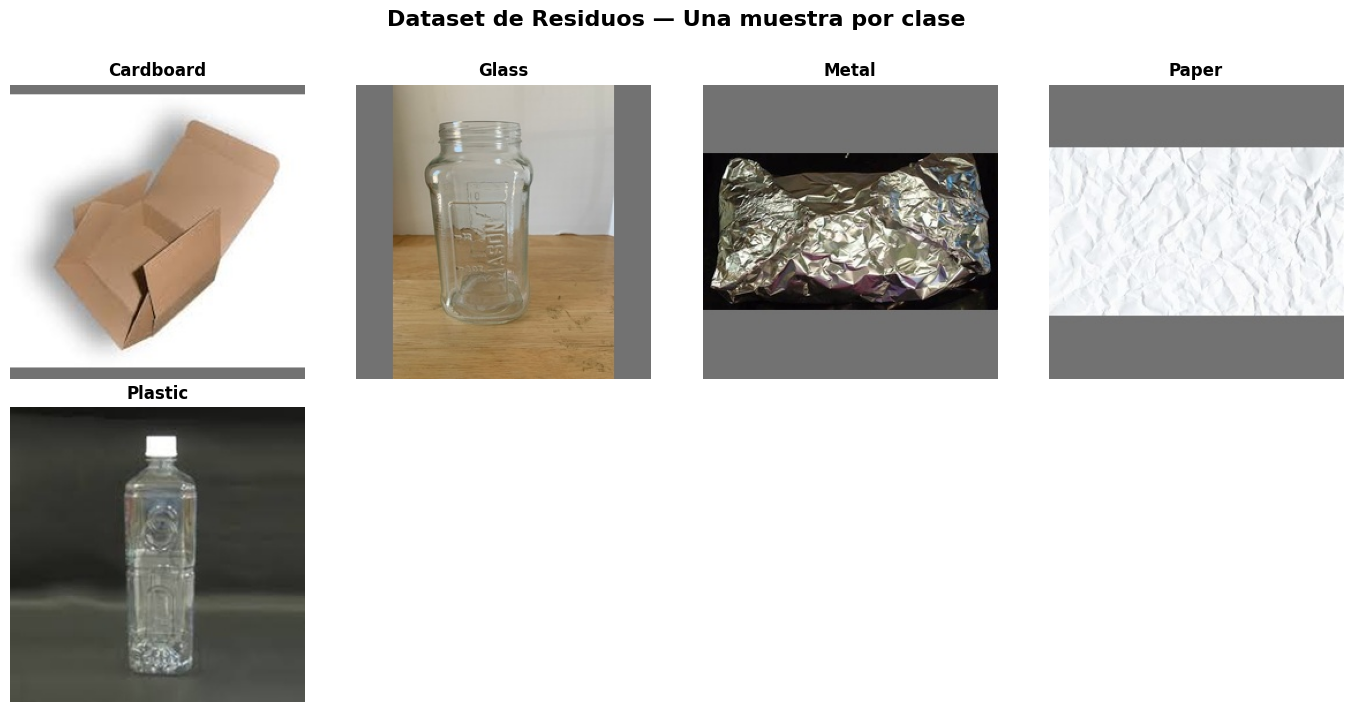


Total clases: 5 | Imágenes en mosaico: 5


In [12]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

BASE_PATH = "Dataset_Ext"

# ── 1. Recolectar una imagen por clase ────────────────────────────
clases = sorted([f for f in os.listdir(BASE_PATH)
                 if os.path.isdir(os.path.join(BASE_PATH, f))])

muestras = {}
for clase in clases:
    class_path = os.path.join(BASE_PATH, clase)
    imagenes   = [f for f in os.listdir(class_path)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if imagenes:
        img_path = os.path.join(class_path, random.choice(imagenes))
        muestras[clase] = img_path

print(f"Clases encontradas: {list(muestras.keys())}")

# ── 2. Mosaico ────────────────────────────────────────────────────
n      = len(muestras)
n_cols = 4
n_rows = -(-n // n_cols)   # ceil division

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(n_cols * 3.5, n_rows * 3.5))
axes = axes.flatten()

for idx, (clase, path) in enumerate(muestras.items()):
    img = Image.open(path).convert("RGB")
    img = img.resize((256, 256))

    axes[idx].imshow(img)
    axes[idx].set_title(clase.replace("_", " ").title(),
                        fontsize=12, fontweight="bold", pad=6)
    axes[idx].axis("off")

    # Borde de color por clase
    for spine in axes[idx].spines.values():
        spine.set_visible(True)
        spine.set_linewidth(3)
        spine.set_edgecolor(plt.cm.tab10(idx / n))

# Ocultar subplots vacíos
for idx in range(len(muestras), len(axes)):
    axes[idx].set_visible(False)

fig.suptitle("Dataset de Residuos — Una muestra por clase",
             fontsize=16, fontweight="bold", y=1.01)

plt.tight_layout()

plt.show()

print(f"\nTotal clases: {n} | Imágenes en mosaico: {len(muestras)}")

# Guardar caracteristicas

In [ ]:
all_features = []
all_labels   = []

print("Extrayendo features con ResNet50...")

with torch.no_grad():
    for i, (imgs, labels_batch) in enumerate(loader):
        imgs = imgs.to(device)

        feats = resnet(imgs)                 # (batch, 2048, 1, 1)
        feats = feats.squeeze(-1).squeeze(-1)  # (batch, 2048)

        all_features.append(feats.cpu().numpy())
        all_labels.extend(labels_batch)

        if i % 5 == 0:
            print(f"  Batch {i+1}/{len(loader)}...")

X = np.vstack(all_features)
labels = np.array(all_labels)

le = LabelEncoder()
y  = le.fit_transform(labels)

print(f"\n Features shape: {X.shape}")   # (N_imágenes, 2048)
print(f"   Clases: {list(zip(le.classes_, le.transform(le.classes_)))}")

Extrayendo features con ResNet50...
  Batch 1/110...
  Batch 6/110...
  Batch 11/110...
  Batch 16/110...
  Batch 21/110...
  Batch 26/110...
  Batch 31/110...
  Batch 36/110...
  Batch 41/110...
  Batch 46/110...
  Batch 51/110...
  Batch 56/110...
  Batch 61/110...
  Batch 66/110...
  Batch 71/110...
  Batch 76/110...
  Batch 81/110...
  Batch 86/110...
  Batch 91/110...
  Batch 96/110...
  Batch 101/110...
  Batch 106/110...

 Features shape: (7010, 2048)
   Clases: [(np.str_('cardboard'), np.int64(0)), (np.str_('glass'), np.int64(1)), (np.str_('metal'), np.int64(2)), (np.str_('paper'), np.int64(3)), (np.str_('plastic'), np.int64(4))]


# Guardar vector

In [ ]:
import numpy as np

np.savez_compressed(
    "features_resnet.npz",
    X=X,
    y=y,
    labels=labels,
    classes=le.classes_
)

print("Guardado: features_resnet50.npz")

Guardado: features_resnet50.npz


# Carga de vector

In [ ]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

# ── Cargar el archivo ─────────────────────────────────────────────
data = np.load("features_resnet.npz", allow_pickle=True)

X      = data["X"]
y      = data["y"]
labels = data["labels"]


le = LabelEncoder()
le.classes_ = data["classes"]


print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Clases  : {le.classes_}")

X shape : (7010, 2048)
y shape : (7010,)
Clases  : ['cardboard' 'glass' 'metal' 'paper' 'plastic']


# Distribucion de datos

Calculando t-SNE... (puede tardar 1-2 min)


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


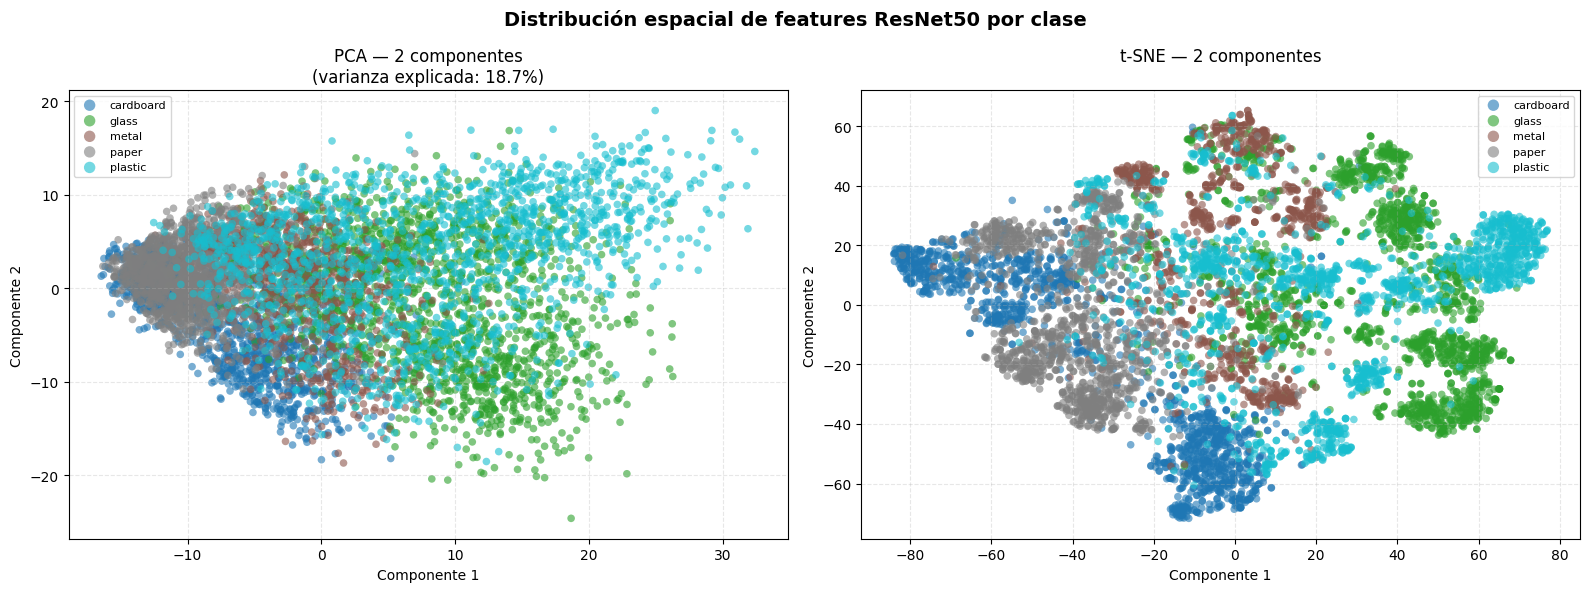

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# ── Reducción de dimensionalidad ──────────────────────────────────

pca_pre = PCA(n_components=50, random_state=42)
X_pca50 = pca_pre.fit_transform(X)

print("Calculando t-SNE... (puede tardar 1-2 min)")
tsne    = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
X_tsne  = tsne.fit_transform(X_pca50)

pca2    = PCA(n_components=2, random_state=42)
X_pca2  = pca2.fit_transform(X)

# ── Colores por clase ─────────────────────────────────────────────
clases  = le.classes_
n_clases = len(clases)
colores = plt.cm.tab10(np.linspace(0, 1, n_clases))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, X_red, titulo, varianza in zip(
    axes,
    [X_pca2, X_tsne],
    ["PCA — 2 componentes", "t-SNE — 2 componentes"],
    [f"(varianza explicada: {pca2.explained_variance_ratio_.sum()*100:.1f}%)", ""]
):
    for i, (clase, color) in enumerate(zip(clases, colores)):
        mask = y == i
        ax.scatter(
            X_red[mask, 0], X_red[mask, 1],
            label      = clase,
            color      = color,
            alpha      = 0.6,
            s          = 30,
            edgecolors = "none"
        )

    ax.set_title(f"{titulo}\n{varianza}", fontsize=12)
    ax.set_xlabel("Componente 1")
    ax.set_ylabel("Componente 2")
    ax.legend(loc="best", fontsize=8, markerscale=1.5)
    ax.grid(True, linestyle="--", alpha=0.3)

plt.suptitle("Distribución espacial de features ResNet50 por clase", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/distribucion_features.png", dpi=150, bbox_inches="tight")
plt.show()

# Train SPLIT

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train_sc.shape[0]} muestras")
print(f"Test:  {X_test_sc.shape[0]} muestras")

Train: 5608 muestras
Test:  1402 muestras


# Grid Search

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# ── Grids de hiperparámetros ──────────────────────────────────────
param_grids = {
    "Gaussian Naive Bayes": {
        "model": GaussianNB(),
        "params": {
            "var_smoothing": [1e-11, 1e-9, 1e-7, 1e-5]
        }
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(random_state=42),
        "params": {
            "max_depth":        [10, 20, 30, None],
            "min_samples_split":[2, 5, 10],
            "criterion":        ["gini", "entropy"]
        }
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42, n_jobs=-1),
        "params": {
            "n_estimators":     [100, 200, 300],
            "max_depth":        [10, 20, None],
            "min_samples_split":[2, 5],
        }
    },
    "SVM": {
        "model": SVC(random_state=42),
        "params": {
            "C":      [0.1, 1, 10, 100],
            "gamma":  ["scale", "auto"],
            "kernel": ["rbf", "poly"]
        }
    },
}

# ── GridSearch ────────────────────────────────────────────────────
resultados_gs = {}

for nombre, cfg in param_grids.items():
    print(f"\n{'─'*50}")
    print(f"  GridSearch: {nombre}")
    print(f"{'─'*50}")

    gs = GridSearchCV(
        estimator  = cfg["model"],
        param_grid = cfg["params"],
        cv         = 5,               # 5-fold cross validation
        scoring    = "accuracy",
        n_jobs     = -1,
        verbose    = 1
    )

    gs.fit(X_train_sc, y_train)

    # Evaluar mejor modelo en test
    best_model = gs.best_estimator_
    y_pred     = best_model.predict(X_test_sc)
    acc        = accuracy_score(y_test, y_pred)

    resultados_gs[nombre] = {
        "best_params": gs.best_params_,
        "cv_score":    gs.best_score_,
        "test_acc":    acc,
        "y_pred":      y_pred,
        "model":       best_model
    }

    print(f"\n  Mejores parámetros : {gs.best_params_}")
    print(f"  CV Accuracy        : {gs.best_score_:.4f}")
    print(f"  Test Accuracy      : {acc:.4f}")
    print(f"\n{classification_report(y_test, y_pred, target_names=le.classes_)}")


# ── Tabla comparativa ─────────────────────────────────────────────
resumen = pd.DataFrame([
    {
        "Modelo":        nombre,
        "CV Accuracy":   f"{v['cv_score']:.4f}",
        "Test Accuracy": f"{v['test_acc']:.4f}",
        "Mejores Params": v["best_params"]
    }
    for nombre, v in resultados_gs.items()
])

print("\n" + "═"*60)
print("  RESUMEN FINAL")
print("═"*60)
print(resumen.to_string(index=False))

# CROSS VALIDATION


──────────────────────────────────────────────────
  Cross-Validation: Gaussian Naive Bayes
──────────────────────────────────────────────────

  Métrica          Fold 1  Fold 2  Fold 3  Fold 4  Fold 5    Media    ±Std
  ───────────────────────────────────────────────────────────────────────────
  Accuracy        0.7754  0.7522  0.7522  0.7627  0.7574  0.7600  ±0.0086
  Precision       0.7753  0.7595  0.7562  0.7704  0.7617  0.7646  ±0.0071
  Recall          0.7810  0.7609  0.7590  0.7716  0.7703  0.7685  ±0.0080
  F1              0.7703  0.7481  0.7477  0.7594  0.7555  0.7562  ±0.0083
  Specificity     0.9446  0.9396  0.9394  0.9417  0.9404  0.9412  ±0.0019

──────────────────────────────────────────────────
  Cross-Validation: Decision Tree
──────────────────────────────────────────────────

  Métrica          Fold 1  Fold 2  Fold 3  Fold 4  Fold 5    Media    ±Std
  ───────────────────────────────────────────────────────────────────────────
  Accuracy        0.6506  0.6702  0.6373 

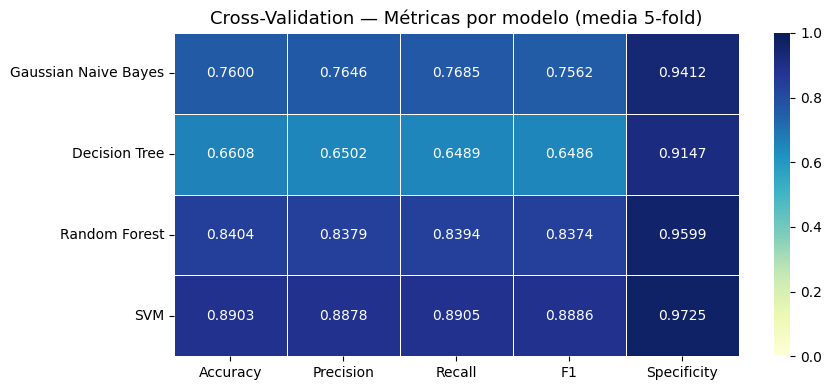

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (make_scorer, accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# ── Modelos base (sin GridSearch) ─────────────────────────────────
modelos = {
    "Gaussian Naive Bayes": GaussianNB(),
    "Decision Tree":        DecisionTreeClassifier(max_depth=20, random_state=42),
    "Random Forest":        RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "SVM":                  SVC(kernel="rbf", C=10, gamma="scale", random_state=42),
}

# ── Especificidad ─────────────────────────────────────────────────
def specificity_macro(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    specs = []
    for i in range(len(cm)):
        TP = cm[i, i]
        FP = cm[:, i].sum() - TP
        TN = cm.sum() - cm[i, :].sum() - FP
        specs.append(TN / (TN + FP + 1e-9))
    return np.mean(specs)

# ── Scorers ───────────────────────────────────────────────────────
scoring = {
    "accuracy":    make_scorer(accuracy_score),
    "precision":   make_scorer(precision_score,  average="macro", zero_division=0),
    "recall":      make_scorer(recall_score,     average="macro", zero_division=0),
    "f1":          make_scorer(f1_score,         average="macro", zero_division=0),
    "specificity": make_scorer(specificity_macro),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Cross Validation ──────────────────────────────────────────────
resultados_cv = {}

for nombre, modelo in modelos.items():
    print(f"\n{'─'*50}")
    print(f"  Cross-Validation: {nombre}")
    print(f"{'─'*50}")

    scores = cross_validate(
        estimator          = modelo,
        X                  = X_train_sc,
        y                  = y_train,
        cv                 = cv,
        scoring            = scoring,
        n_jobs             = -1,
        return_train_score = False
    )

    metricas = {}
    print(f"\n  {'Métrica':<15} {'Fold 1':>7} {'Fold 2':>7} {'Fold 3':>7} {'Fold 4':>7} {'Fold 5':>7}  {'Media':>7} {'±Std':>7}")
    print(f"  {'─'*75}")

    for metrica in scoring:
        vals = scores[f"test_{metrica}"]
        metricas[metrica] = {"mean": vals.mean(), "std": vals.std()}
        folds_str = "  ".join([f"{v:.4f}" for v in vals])
        print(f"  {metrica.capitalize():<15} {folds_str}  {vals.mean():.4f}  ±{vals.std():.4f}")

    resultados_cv[nombre] = metricas

# ── Tabla resumen ─────────────────────────────────────────────────
filas = []
for nombre, metricas in resultados_cv.items():
    fila = {"Modelo": nombre}
    for metrica, vals in metricas.items():
        fila[metrica.capitalize()] = f"{vals['mean']:.4f} ±{vals['std']:.4f}"
    filas.append(fila)

resumen_cv = pd.DataFrame(filas).set_index("Modelo")
print(f"\n\n{'═'*70}")
print("  RESUMEN COMPARATIVO — CV (media ± std)")
print(f"{'═'*70}")
print(resumen_cv.to_string())

# ── Heatmap ───────────────────────────────────────────────────────
heat_data = pd.DataFrame({
    nombre: {m.capitalize(): v["mean"] for m, v in metricas.items()}
    for nombre, metricas in resultados_cv.items()
}).T

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(heat_data, annot=True, fmt=".4f", cmap="YlGnBu",
            vmin=0, vmax=1, ax=ax, linewidths=0.5)
ax.set_title("Cross-Validation — Métricas por modelo (media 5-fold)", fontsize=13)
plt.tight_layout()
plt.show()

# Modelos

In [ ]:
modelos = {
    "Gaussian Naive Bayes": GaussianNB(),
    "Decision Tree":        DecisionTreeClassifier(max_depth=20, random_state=42),
    "Random Forest":        RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "SVM":                  SVC(kernel="rbf", C=10, gamma="scale", random_state=42),
}


resultados = {}

for nombre, modelo in modelos.items():
    print(f"\n{'─'*45}")
    print(f"  Entrenando: {nombre}")
    print(f"{'─'*45}")

    modelo.fit(X_train_sc, y_train)
    y_pred = modelo.predict(X_test_sc)
    acc = accuracy_score(y_test, y_pred)
    resultados[nombre] = {"y_pred": y_pred, "acc": acc}

    print(f"Accuracy: {acc:.4f}\n")
    print(classification_report(y_test, y_pred, target_names=le.classes_))


─────────────────────────────────────────────
  Entrenando: Gaussian Naive Bayes
─────────────────────────────────────────────
Accuracy: 0.7603

              precision    recall  f1-score   support

   cardboard       0.83      0.74      0.78       282
       glass       0.90      0.72      0.80       347
       metal       0.59      0.85      0.70       186
       paper       0.69      0.83      0.76       267
     plastic       0.80      0.70      0.75       320

    accuracy                           0.76      1402
   macro avg       0.76      0.77      0.76      1402
weighted avg       0.78      0.76      0.76      1402


─────────────────────────────────────────────
  Entrenando: Decision Tree
─────────────────────────────────────────────
Accuracy: 0.6648

              precision    recall  f1-score   support

   cardboard       0.70      0.68      0.69       282
       glass       0.72      0.71      0.72       347
       metal       0.59      0.62      0.60       186
       pa

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, precision_recall_fscore_support

modelos = {
    "Gaussian Naive Bayes": GaussianNB(),
    "Decision Tree":        DecisionTreeClassifier(max_depth=20, random_state=42),
    "Random Forest":        RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "SVM":                  SVC(kernel="rbf", C=10, gamma="scale", random_state=42),
}

resultados = {}

for nombre, modelo in modelos.items():
    print(f"\n{'─'*45}")
    print(f"   Entrenando: {nombre}")
    print(f"{'─'*45}")

    # Entrenamiento y predicción
    modelo.fit(X_train_sc, y_train)
    y_pred = modelo.predict(X_test_sc)

    acc = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')

    # Guardamos TODO en el diccionario para que el código de la gráfica lo encuentre
    resultados[nombre] = {
        "y_pred": y_pred,
        "acc": acc,
        "pre": precision,
        "rec": recall,
        "f1": f1
    }

    print(f"Accuracy: {acc:.4f}\n")
    print(classification_report(y_test, y_pred, target_names=le.classes_))


─────────────────────────────────────────────
   Entrenando: Gaussian Naive Bayes
─────────────────────────────────────────────
Accuracy: 0.7603

              precision    recall  f1-score   support

   cardboard       0.83      0.74      0.78       282
       glass       0.90      0.72      0.80       347
       metal       0.59      0.85      0.70       186
       paper       0.69      0.83      0.76       267
     plastic       0.80      0.70      0.75       320

    accuracy                           0.76      1402
   macro avg       0.76      0.77      0.76      1402
weighted avg       0.78      0.76      0.76      1402


─────────────────────────────────────────────
   Entrenando: Decision Tree
─────────────────────────────────────────────
Accuracy: 0.6648

              precision    recall  f1-score   support

   cardboard       0.70      0.68      0.69       282
       glass       0.72      0.71      0.72       347
       metal       0.59      0.62      0.60       186
       

In [ ]:
#MLP

# GRAFICAS

/tmp/ipykernel_524/3887925740.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(nombres, rotation=15, ha="right")


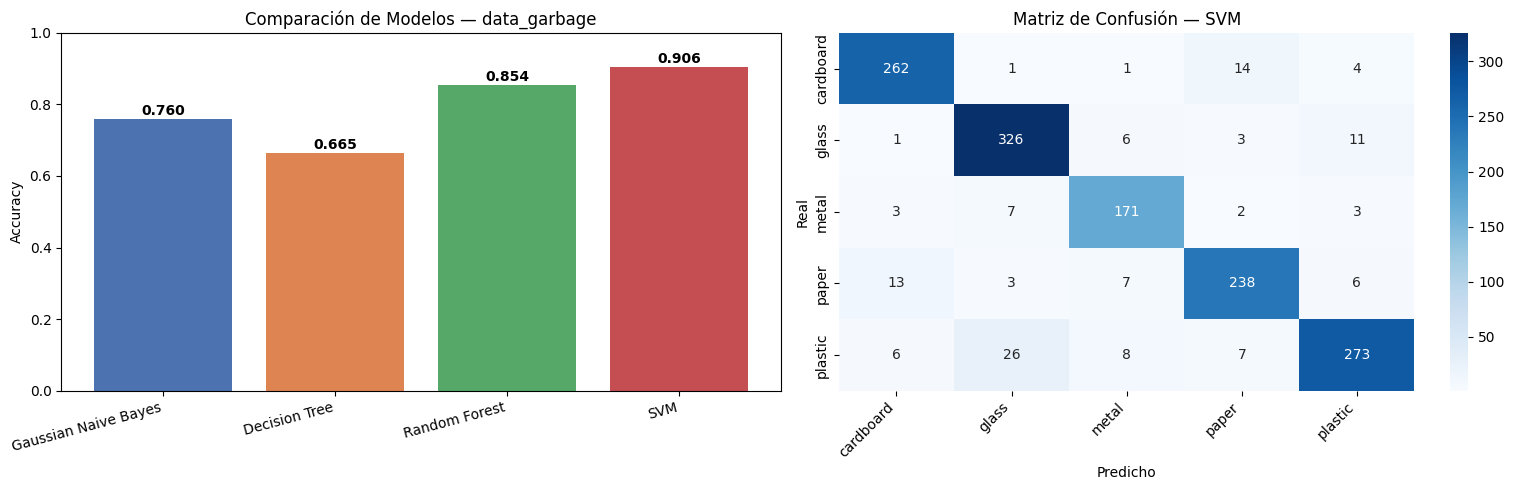


 Mejor modelo: SVM con accuracy 0.9058


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Barras de accuracy
nombres = list(resultados.keys())
accs    = [resultados[n]["acc"] for n in nombres]
colores = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

bars = axes[0].bar(nombres, accs, color=colores)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Comparación de Modelos — data_garbage")
axes[0].set_xticklabels(nombres, rotation=15, ha="right")
for bar, acc in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{acc:.3f}", ha="center", fontweight="bold")

# Mejor modelo → matriz de confusión
mejor = max(resultados, key=lambda n: resultados[n]["acc"])
cm = confusion_matrix(y_test, resultados[mejor]["y_pred"])
sns.heatmap(cm, annot=True, fmt="d", ax=axes[1],
            xticklabels=le.classes_, yticklabels=le.classes_, cmap="Blues")
axes[1].set_title(f"Matriz de Confusión — {mejor}")
axes[1].set_xlabel("Predicho"); axes[1].set_ylabel("Real")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/resultados_modelos.png", dpi=150)
plt.show()

print(f"\n Mejor modelo: {mejor} con accuracy {resultados[mejor]['acc']:.4f}")

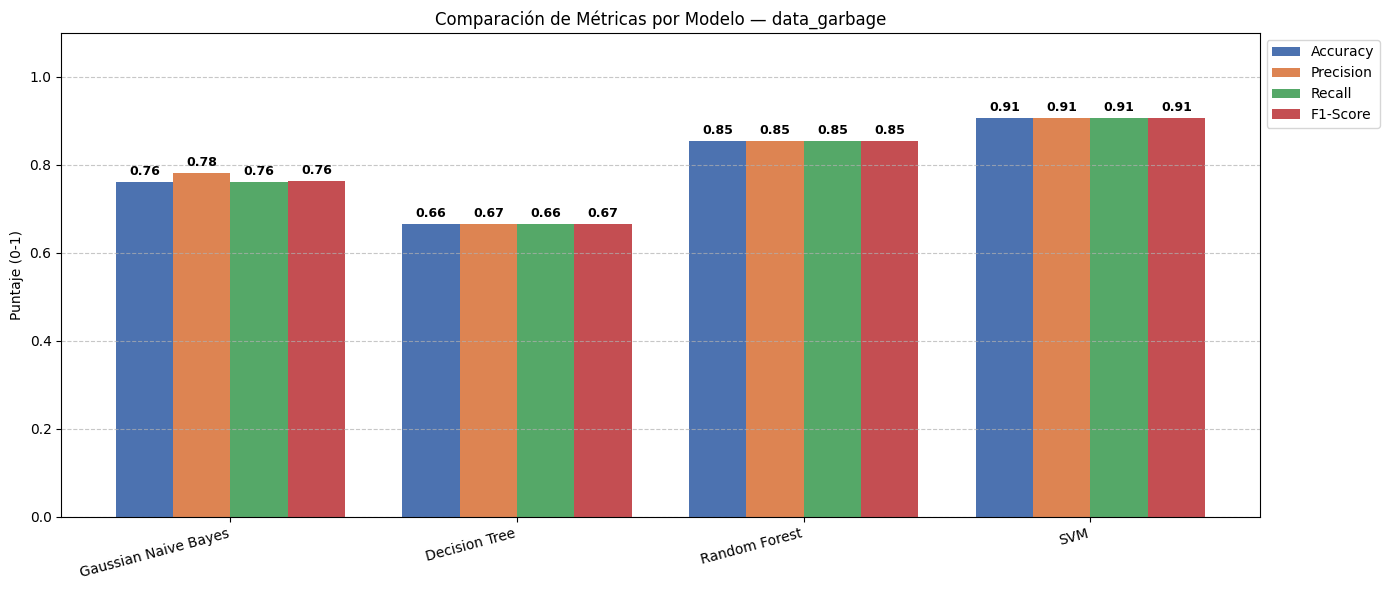


 Mejor modelo: SVM con accuracy 0.9058


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Configuración de los datos
modelos = list(resultados.keys())
metricas = ['acc', 'pre', 'rec', 'f1']
n_modelos = len(modelos)
n_metricas = len(metricas)

# Configuración del gráfico
fig, ax = plt.subplots(figsize=(14, 6))
width = 0.2  # Ancho de cada barra
x = np.arange(n_modelos)

# Colores para las métricas
colores = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

# Graficar cada métrica
for i, metrica in enumerate(metricas):
    valores = [resultados[m][metrica] for m in modelos]
    rects = ax.bar(x + i * width, valores, width, label=labels[i], color=colores[i])

    # Añadir etiquetas de texto sobre las barras
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 puntos de desfase vertical
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

# Detalles del gráfico
ax.set_ylabel('Puntaje (0-1)')
ax.set_title('Comparación de Métricas por Modelo — data_garbage')
ax.set_xticks(x + (width * (n_metricas - 1) / 2))
ax.set_xticklabels(modelos, rotation=15, ha="right")
ax.set_ylim(0, 1.1)  # Espacio extra para las etiquetas
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Identificar el mejor basándose en Accuracy
mejor = max(resultados, key=lambda n: resultados[n]["acc"])
print(f"\n Mejor modelo: {mejor} con accuracy {resultados[mejor]['acc']:.4f}")

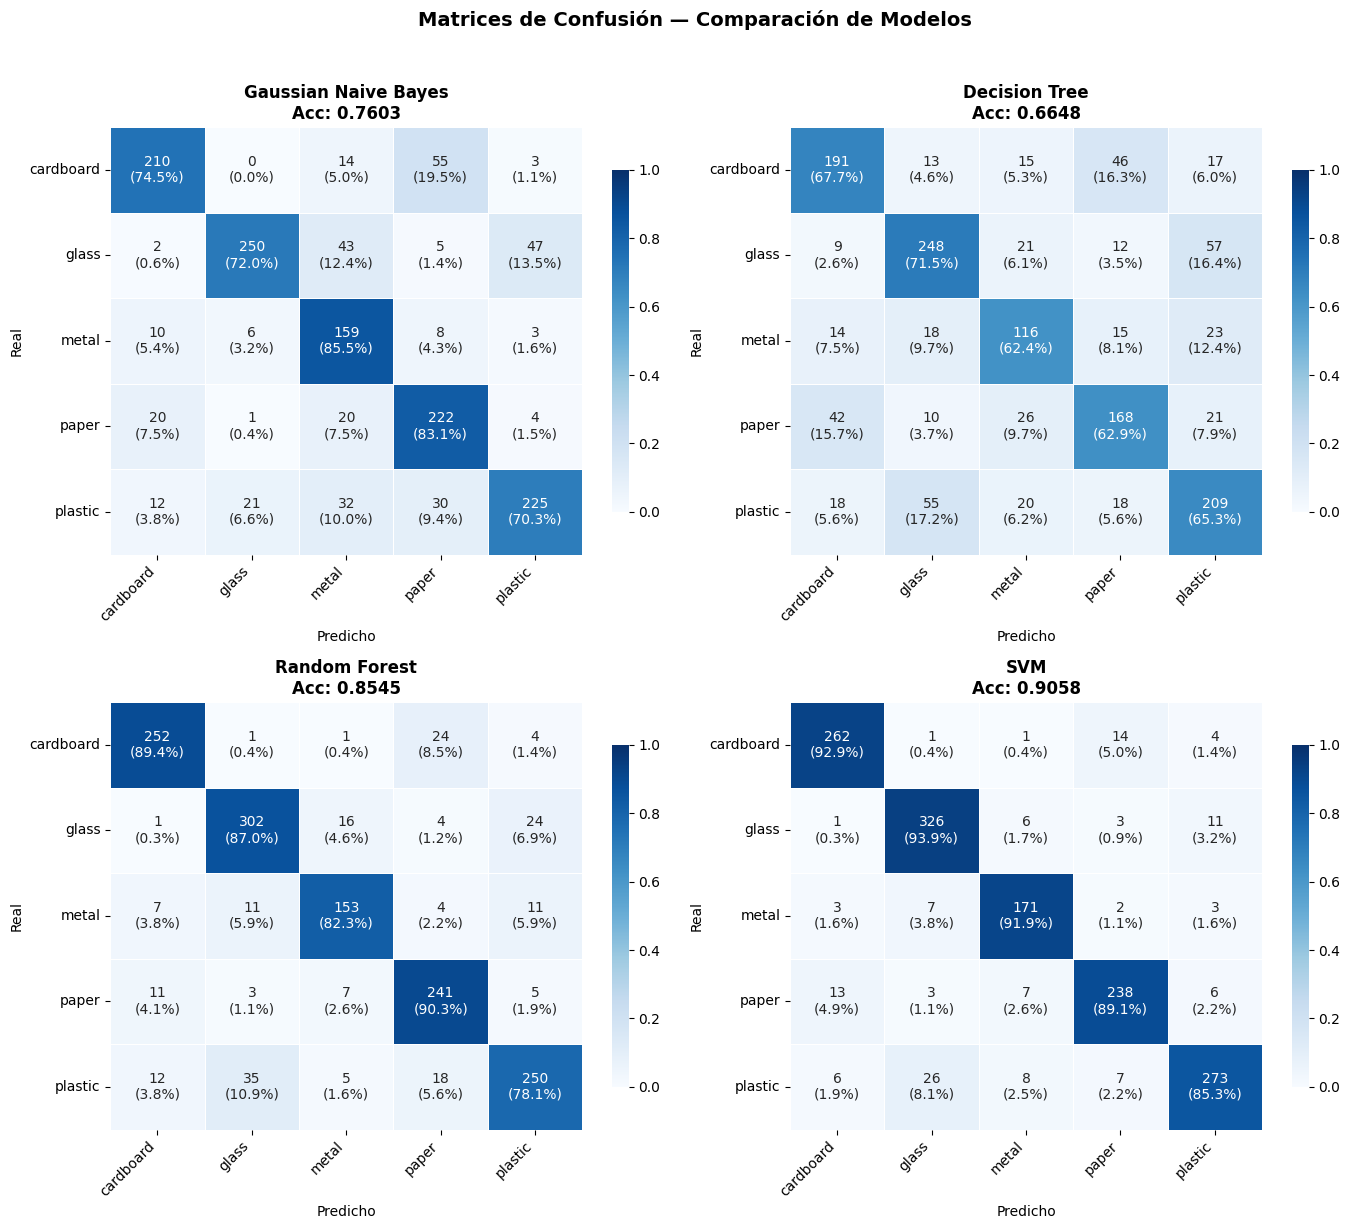

In [ ]:
import math

modelos_nombres = list(resultados.items())
n_modelos       = len(modelos_nombres)

# Una fila por cada 2 modelos
n_cols = 2
n_rows = math.ceil(n_modelos / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 6 * n_rows))
axes = axes.flatten()  # facilita iterar aunque sea 1 sola fila

for idx, (nombre, vals) in enumerate(resultados.items()):
    cm = confusion_matrix(y_test, vals["y_pred"])

    # Normalizar para ver porcentajes además de conteos
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    # Anotaciones: conteo + porcentaje
    annot = np.empty_like(cm, dtype=object)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot[i, j] = f"{cm[i,j]}\n({cm_norm[i,j]*100:.1f}%)"

    sns.heatmap(
        cm_norm,
        annot      = annot,
        fmt        = "",
        ax         = axes[idx],
        cmap       = "Blues",
        vmin       = 0, vmax = 1,
        xticklabels = le.classes_,
        yticklabels = le.classes_,
        linewidths  = 0.5,
        cbar_kws    = {"shrink": 0.8}
    )

    axes[idx].set_title(f"{nombre}\nAcc: {vals['acc']:.4f}", fontsize=12, fontweight="bold")
    axes[idx].set_xlabel("Predicho")
    axes[idx].set_ylabel("Real")
    axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45, ha="right")
    axes[idx].set_yticklabels(axes[idx].get_yticklabels(), rotation=0)

# Ocultar subplots vacíos si el número de modelos es impar
for idx in range(n_modelos, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("Matrices de Confusión — Comparación de Modelos", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/confusion_matrices_todos.png", dpi=150, bbox_inches="tight")
plt.show()

# Cross Validation vs Train-Split

                      Accuracy  Precision  Recall      F1  Specificity
Modelo                                                                
Gaussian Naive Bayes    0.7600     0.7646  0.7685  0.7562       0.9412
Decision Tree           0.6608     0.6502  0.6489  0.6486       0.9147
Random Forest           0.8404     0.8379  0.8394  0.8374       0.9599
SVM                     0.8903     0.8878  0.8905  0.8886       0.9725


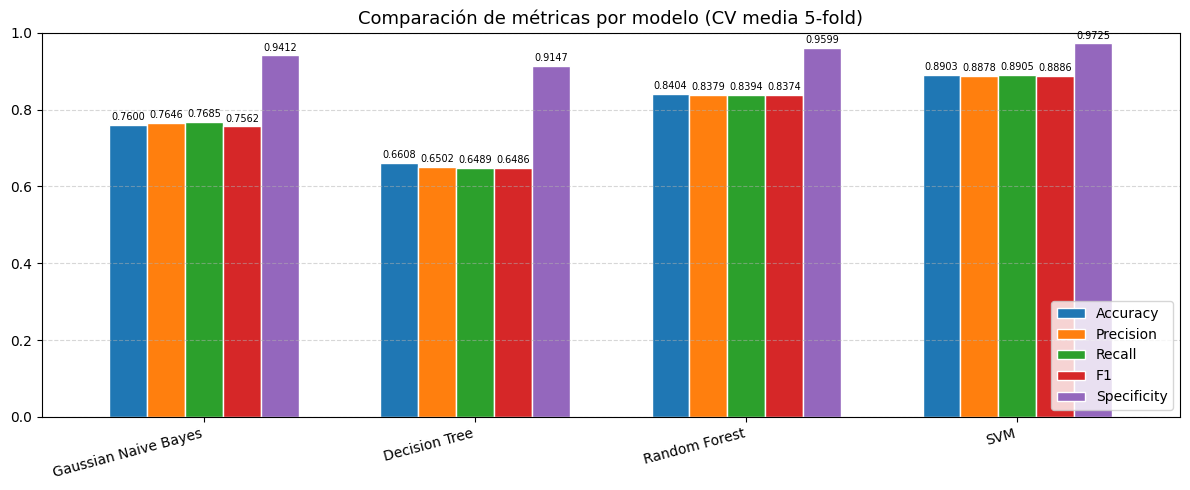

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

filas = []

for nombre, metricas in resultados_cv.items():
    filas.append({
        "Modelo":      nombre,
        "Accuracy":    round(metricas["accuracy"]["mean"], 4),
        "Precision":   round(metricas["precision"]["mean"], 4),
        "Recall":      round(metricas["recall"]["mean"], 4),
        "F1":          round(metricas["f1"]["mean"], 4),
        "Specificity": round(metricas["specificity"]["mean"], 4),
    })

resumen = pd.DataFrame(filas).set_index("Modelo")
print(resumen.to_string())

# ── Gráfico de barras ─────────────────────────────────────────────
ax = resumen.plot(
    kind      = "bar",
    figsize   = (12, 5),
    ylim      = (0, 1),
    edgecolor = "white",
    width     = 0.7
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", fontsize=7, padding=2)

ax.set_title("Comparación de métricas por modelo (CV media 5-fold)", fontsize=13)
ax.set_xlabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")
ax.legend(loc="lower right")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

  Gaussian Naive Bayes      Test Acc: 0.7603
  Decision Tree             Test Acc: 0.6648
  Random Forest             Test Acc: 0.8545
  SVM                       Test Acc: 0.9058
                      CV Accuracy  Test Accuracy  Diferencia
Modelo                                                      
Gaussian Naive Bayes       0.7600         0.7603      0.0003
Decision Tree              0.6608         0.6648      0.0040
Random Forest              0.8404         0.8545      0.0141
SVM                        0.8903         0.9058      0.0155


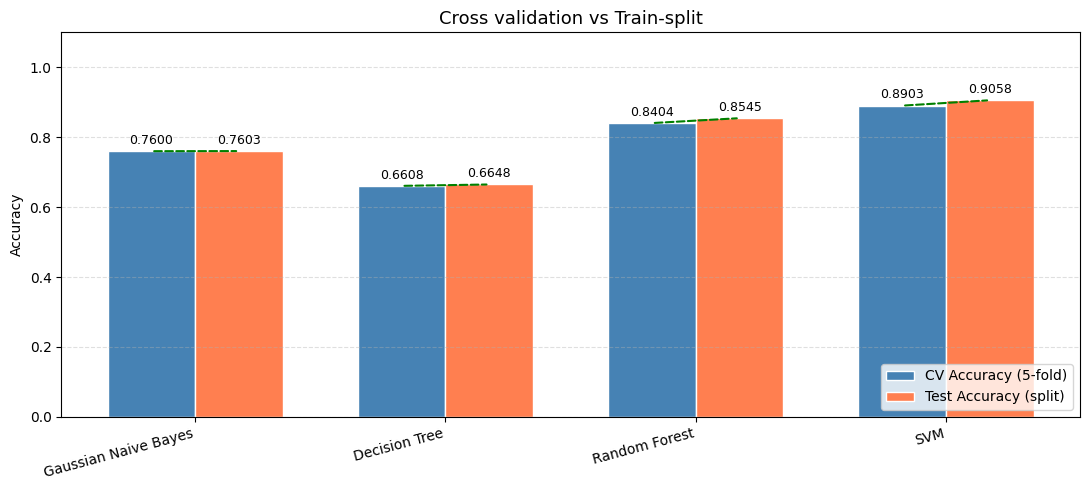

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# ── Entrenar y evaluar en train/test split ────────────────────────
modelos = {
    "Gaussian Naive Bayes": GaussianNB(),
    "Decision Tree":        DecisionTreeClassifier(max_depth=20, random_state=42),
    "Random Forest":        RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "SVM":                  SVC(kernel="rbf", C=10, gamma="scale", random_state=42),
}

acc_split = {}
for nombre, modelo in modelos.items():
    modelo.fit(X_train_sc, y_train)
    y_pred = modelo.predict(X_test_sc)
    acc_split[nombre] = accuracy_score(y_test, y_pred)
    print(f"  {nombre:<25} Test Acc: {acc_split[nombre]:.4f}")

# ── Construir tabla comparativa ───────────────────────────────────
filas = []
for nombre in modelos:
    filas.append({
        "Modelo":       nombre,
        "CV Accuracy":  round(resultados_cv[nombre]["accuracy"]["mean"], 4),
        "TSplit Accuracy": round(acc_split[nombre], 4),
    })

resumen = pd.DataFrame(filas).set_index("Modelo")
resumen["Diferencia"] = resumen["TSplit Accuracy"] - resumen["CV Accuracy"]
print(resumen.to_string())

# ── Gráfico ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

x      = range(len(resumen))
width  = 0.35
nombres = resumen.index.tolist()

bars1 = ax.bar([i - width/2 for i in x], resumen["CV Accuracy"],
               width=width, label="CV Accuracy (5-fold)",
               color="steelblue", edgecolor="white")

bars2 = ax.bar([i + width/2 for i in x], resumen["TSplit Accuracy"],
               width=width, label="TSplit Accuracy (split)",
               color="coral", edgecolor="white")

# Etiquetas sobre barras
ax.bar_label(bars1, fmt="%.4f", fontsize=9, padding=3)
ax.bar_label(bars2, fmt="%.4f", fontsize=9, padding=3)

# Línea de diferencia
for i, (cv, test) in enumerate(zip(resumen["CV Accuracy"], resumen["TSplit Accuracy"])):
    color = "green" if test >= cv else "red"
    ax.annotate("", xy=(i + width/2, test), xytext=(i - width/2, cv),
                arrowprops=dict(arrowstyle="-", color=color, lw=1.5, linestyle="dashed"))

ax.set_xticks(list(x))
ax.set_xticklabels(nombres, rotation=15, ha="right")
ax.set_ylim(0, 1.1)
ax.set_ylabel("Accuracy")
ax.set_title("Cross validation vs Train-split", fontsize=13)
ax.legend(loc="lower right")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# Comparacion ResNET vs manuales

ResNet50 → (7010, 2048)
Manual   → (7010, 8260)
Clases   → ['cardboard' 'glass' 'metal' 'paper' 'plastic']

Entrenando: Gaussian NB
  ResNet50   → Acc: 0.7603
  Manual     → Acc: 0.4001

Entrenando: Decision Tree
  ResNet50   → Acc: 0.6648
  Manual     → Acc: 0.4558

Entrenando: Random Forest
  ResNet50   → Acc: 0.8545
  Manual     → Acc: 0.6327

Entrenando: SVM
  ResNet50   → Acc: 0.9058
  Manual     → Acc: 0.6805


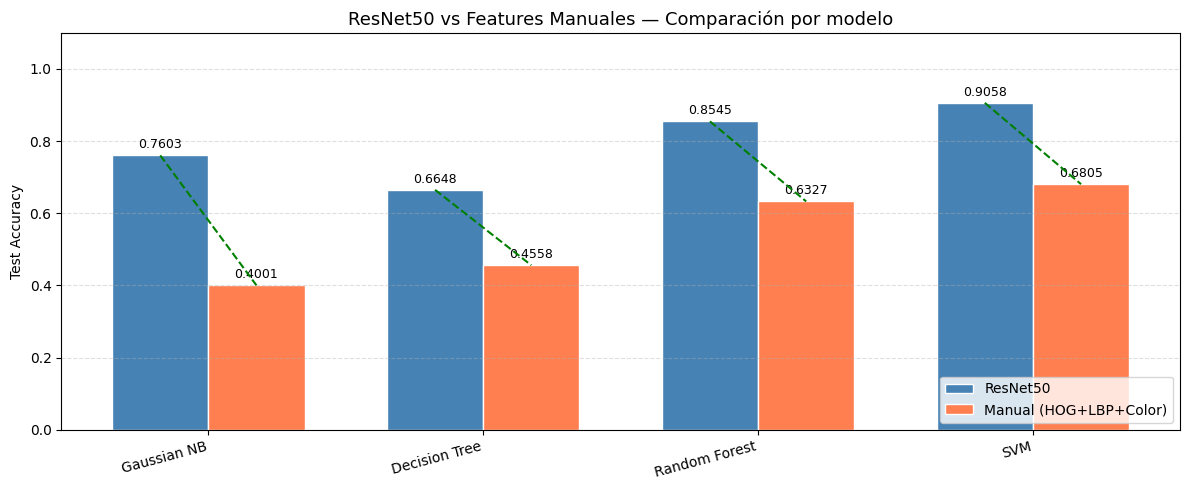


═══════════════════════════════════════════════════════
  ResNet50 vs Manual — Test Accuracy
═══════════════════════════════════════════════════════
              ResNet50  Manual Diferencia
Modelo                                   
Gaussian NB     0.7603  0.4001    +0.3602
Decision Tree   0.6648  0.4558    +0.2090
Random Forest   0.8545  0.6327    +0.2218
SVM             0.9058  0.6805    +0.2254


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# ── 1. Cargar ambos archivos ──────────────────────────────────────
data_resnet  = np.load("features_resnet.npz", allow_pickle=True)
data_manual  = np.load("features_manual.npz",   allow_pickle=True)

X_resnet  = data_resnet["X"]
y_resnet  = data_resnet["y"]

X_manual  = data_manual["X"]
y_manual  = data_manual["y"]

le = LabelEncoder()
le.classes_ = data_resnet["classes"]

print(f"ResNet50 → {X_resnet.shape}")
print(f"Manual   → {X_manual.shape}")
print(f"Clases   → {le.classes_}")


# ── 2. Split + Escalar para cada conjunto ────────────────────────
def preparar(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    sc         = StandardScaler()
    X_train_sc = sc.fit_transform(X_train)
    X_test_sc  = sc.transform(X_test)
    return X_train_sc, X_test_sc, y_train, y_test

X_train_r, X_test_r, y_train_r, y_test_r = preparar(X_resnet, y_resnet)
X_train_m, X_test_m, y_train_m, y_test_m = preparar(X_manual, y_manual)


# ── 3. Modelos ────────────────────────────────────────────────────
modelos = {
    "Gaussian NB":   GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(max_depth=20, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "SVM":           SVC(kernel="rbf", C=10, gamma="scale", random_state=42),
}


# ── 4. Entrenar y evaluar en ambos conjuntos ──────────────────────
import copy

resultados = {}   # { modelo: { "ResNet50": acc, "Manual": acc } }

for nombre, modelo in modelos.items():
    print(f"\nEntrenando: {nombre}")
    accs = {}

    for etiqueta, (X_tr, X_te, y_tr, y_te) in zip(
        ["ResNet50", "Manual"],
        [(X_train_r, X_test_r, y_train_r, y_test_r),
         (X_train_m, X_test_m, y_train_m, y_test_m)]
    ):
        m = copy.deepcopy(modelo)       # modelo fresco para cada conjunto
        m.fit(X_tr, y_tr)
        acc = accuracy_score(y_te, m.predict(X_te))
        accs[etiqueta] = acc
        print(f"  {etiqueta:<10} → Acc: {acc:.4f}")

    resultados[nombre] = accs


# ── 5. Plot comparativo ───────────────────────────────────────────
nombres  = list(resultados.keys())
acc_res  = [resultados[n]["ResNet50"] for n in nombres]
acc_man  = [resultados[n]["Manual"]   for n in nombres]

x      = np.arange(len(nombres))
width  = 0.35

fig, ax = plt.subplots(figsize=(12, 5))

bars1 = ax.bar(x - width/2, acc_res, width, label="ResNet50",
               color="steelblue", edgecolor="white")
bars2 = ax.bar(x + width/2, acc_man, width, label="Manual (HOG+LBP+Color)",
               color="coral",     edgecolor="white")

ax.bar_label(bars1, fmt="%.4f", fontsize=9, padding=3)
ax.bar_label(bars2, fmt="%.4f", fontsize=9, padding=3)

# Línea conectando diferencia
for i, (r, m) in enumerate(zip(acc_res, acc_man)):
    color = "green" if r >= m else "red"
    ax.plot([i - width/2, i + width/2], [r, m],
            color=color, lw=1.5, linestyle="--", zorder=5)

ax.set_xticks(x)
ax.set_xticklabels(nombres, rotation=15, ha="right", fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Test Accuracy")
ax.set_title("ResNet50 vs Features Manuales — Comparación por modelo", fontsize=13)
ax.legend(loc="lower right")
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/comparacion_resnet_vs_manual.png",
            dpi=150, bbox_inches="tight")
plt.show()


# ── 6. Tabla resumen ──────────────────────────────────────────────
import pandas as pd

filas = []
for nombre in nombres:
    r   = resultados[nombre]["ResNet50"]
    m   = resultados[nombre]["Manual"]
    filas.append({
        "Modelo":    nombre,
        "ResNet50":  f"{r:.4f}",
        "Manual":    f"{m:.4f}",
        "Diferencia": f"{r - m:+.4f}"
    })

df = pd.DataFrame(filas).set_index("Modelo")
print(f"\n{'═'*55}")
print("  ResNet50 vs Manual — Test Accuracy")
print(f"{'═'*55}")
print(df.to_string())

Manual → (7010, 8260)
Clases → ['cardboard' 'glass' 'metal' 'paper' 'plastic']
  Gaussian NB          → Acc: 0.4001
  Decision Tree        → Acc: 0.4558
  Random Forest        → Acc: 0.6327
  SVM                  → Acc: 0.6805


/tmp/ipykernel_12172/3795971233.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(nombres, rotation=15, ha="right", fontsize=10)


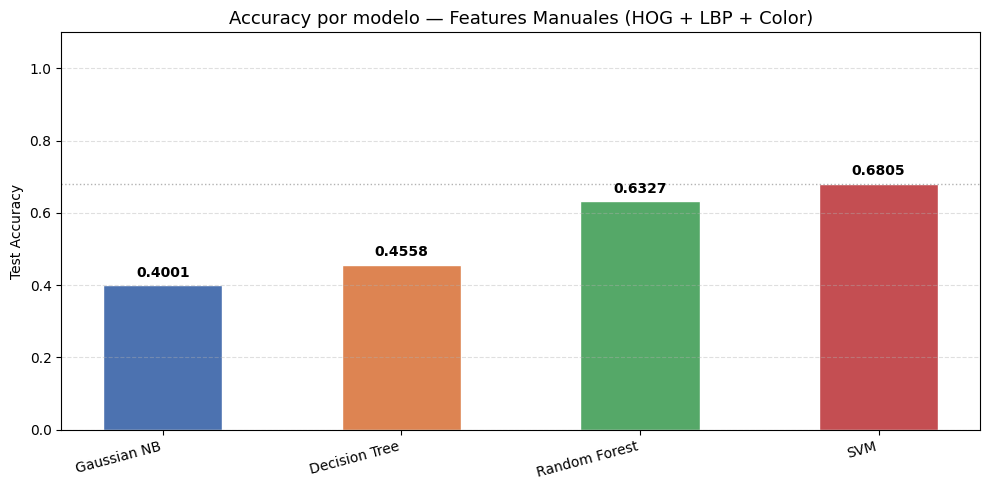

NameError: name 'pd' is not defined

In [5]:
import copy

# ── 1. Cargar features manuales ───────────────────────────────────
data_manual = np.load("features_manual.npz", allow_pickle=True)

X = data_manual["X"]
y = data_manual["y"]

le = LabelEncoder()
le.classes_ = data_manual["classes"]

print(f"Manual → {X.shape}")
print(f"Clases → {le.classes_}")

# ── 2. Split + Escalar ────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
sc         = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc  = sc.transform(X_test)

# ── 3. Modelos ────────────────────────────────────────────────────
modelos = {
    "Gaussian NB":   GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(max_depth=20, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "SVM":           SVC(kernel="rbf", C=10, gamma="scale", random_state=42),
}

# ── 4. Entrenar y evaluar ─────────────────────────────────────────
resultados = {}

for nombre, modelo in modelos.items():
    m   = copy.deepcopy(modelo)
    m.fit(X_train_sc, y_train)
    acc = accuracy_score(y_test, m.predict(X_test_sc))
    resultados[nombre] = acc
    print(f"  {nombre:<20} → Acc: {acc:.4f}")

# ── 5. Plot ───────────────────────────────────────────────────────
nombres = list(resultados.keys())
accs    = [resultados[n] for n in nombres]
colores = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(nombres, accs, color=colores, edgecolor="white", width=0.5)
ax.bar_label(bars, fmt="%.4f", fontsize=10, padding=4, fontweight="bold")

ax.set_ylim(0, 1.1)
ax.set_ylabel("Test Accuracy")
ax.set_title("Accuracy por modelo — Features Manuales (HOG + LBP + Color)", fontsize=13)
ax.set_xticklabels(nombres, rotation=15, ha="right", fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.axhline(y=max(accs), color="gray", linestyle=":", linewidth=1, alpha=0.6)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/accuracy_features_manuales.png",
            dpi=150, bbox_inches="tight")
plt.show()

# ── 6. Tabla resumen ──────────────────────────────────────────────
df = pd.DataFrame([
    {"Modelo": n, "Test Accuracy": f"{acc:.4f}"}
    for n, acc in resultados.items()
]).set_index("Modelo")

print(f"\n{'═'*35}")
print("  Features Manuales — Test Accuracy")
print(f"{'═'*35}")
print(df.to_string())
print(f"\n  Mejor modelo: {max(resultados, key=resultados.get)}")